In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Loading in data
df= pd.read_excel('enrollment_dataset.xlsx')
df.head()

,YR_CDE,Semester,TRM_CDE,CRS_TITLE,CRS_CDE,Section,Course + Section ID,Department,MAX_ENROLLMENT,CRS_ENROLLMENT,LOC_CDE,Enrollment Ratio
0,2023,Fall,UF,INTERMEDIATE ACCOUNTING I,ACTG 3113,1,ACTG 31131,ACTG,24,20,MAIN,0.833333
1,2023,Fall,UF,MANAGERIAL COST ACCOUNTING,ACTG 3133,1,ACTG 31331,ACTG,24,11,MAIN,0.458333
2,2023,Fall,UF,ADVNCD ACCNTNG - FRAMEWORK & REPORT,ACTG 4113,1,ACTG 41131,ACTG,24,9,MAIN,0.375000
3,2023,Fall,UF,FEDERAL INCOME TAXATION I,ACTG 4133,1,ACTG 41331,ACTG,24,10,MAIN,0.416667
4,2023,Fall,UF,AUDITING,ACTG 4153,1,ACTG 41531,ACTG,24,15,MAIN,0.625000


In [ ]:
df= df.rename(columns ={'Course + Section ID': 'Course_and_sectionID',
                        'Enrollment Ratio': 'Enrollment_ratio',
                        'MAX_ENROLLMENT':'Max_enrollment',
                        'CRS_ENROLLMENT': 'Crs_enrollment',
                        'CRS_TITLE': 'Crs_title',
                        'CRS_CDE':'Crs_code',
                        'LOC_CDE': 'Loc_code'})

df.head()

,YR_CDE,Semester,TRM_CDE,Crs_title,Crs_code,Section,Course_and_sectionID,Department,Max_enrollment,Crs_enrollment,Loc_code,Enrollment_ratio
0,2023,Fall,UF,INTERMEDIATE ACCOUNTING I,ACTG 3113,1,ACTG 31131,ACTG,24,20,MAIN,0.833333
1,2023,Fall,UF,MANAGERIAL COST ACCOUNTING,ACTG 3133,1,ACTG 31331,ACTG,24,11,MAIN,0.458333
2,2023,Fall,UF,ADVNCD ACCNTNG - FRAMEWORK & REPORT,ACTG 4113,1,ACTG 41131,ACTG,24,9,MAIN,0.375000
3,2023,Fall,UF,FEDERAL INCOME TAXATION I,ACTG 4133,1,ACTG 41331,ACTG,24,10,MAIN,0.416667
4,2023,Fall,UF,AUDITING,ACTG 4153,1,ACTG 41531,ACTG,24,15,MAIN,0.625000


In [ ]:
df['Demand_gap']= df['Max_enrollment']- df['Crs_enrollment']
df.head()

,YR_CDE,Semester,TRM_CDE,Crs_title,Crs_code,Section,Course_and_sectionID,Department,Max_enrollment,Crs_enrollment,Loc_code,Enrollment_ratio,Demand_gap
0,2023,Fall,UF,INTERMEDIATE ACCOUNTING I,ACTG 3113,1,ACTG 31131,ACTG,24,20,MAIN,0.833333,4
1,2023,Fall,UF,MANAGERIAL COST ACCOUNTING,ACTG 3133,1,ACTG 31331,ACTG,24,11,MAIN,0.458333,13
2,2023,Fall,UF,ADVNCD ACCNTNG - FRAMEWORK & REPORT,ACTG 4113,1,ACTG 41131,ACTG,24,9,MAIN,0.375000,15
3,2023,Fall,UF,FEDERAL INCOME TAXATION I,ACTG 4133,1,ACTG 41331,ACTG,24,10,MAIN,0.416667,14
4,2023,Fall,UF,AUDITING,ACTG 4153,1,ACTG 41531,ACTG,24,15,MAIN,0.625000,9


In [ ]:
location_summary = df.groupby('Loc_code').agg({'Enrollment_ratio': 'mean','Demand_gap': 'sum','Crs_enrollment':'count'})
location_summary.head()

,Enrollment_ratio,Demand_gap,Crs_enrollment
Loc_code,,,
BAIR,0.178571,116,2
BSIDE,0.691891,363,35
BURL,0.000000,40,1
CMBSO,0.453516,291,15
CONW,0.213973,162,4


In [ ]:
location_summary= location_summary.rename(columns={'Crs_enrollment': 'Total_courses',
                                                   'Enrollment_ratio':'Average_utilization',
                                                   'Demand_gap': 'Total_Demand_Gap'})
location_summary.head()

,Average_utilization,Total_Demand_Gap,Total_courses
Loc_code,,,
BAIR,0.178571,116,2
BSIDE,0.691891,363,35
BURL,0.000000,40,1
CMBSO,0.453516,291,15
CONW,0.213973,162,4


In [ ]:
display(location_summary)

,Average_utilization,Total_Demand_Gap,Total_courses
Loc_code,,,
BAIR,0.178571,116,2
BSIDE,0.691891,363,35
BURL,0.000000,40,1
CMBSO,0.453516,291,15
CONW,0.213973,162,4
CORD,0.300655,161,8
DOUG,0.404583,177,8
EHAR,0.020000,98,1
FMND,0.320000,68,1


<Axes: title={'center': 'Average Utilization by Location'}, xlabel='Loc_code'>

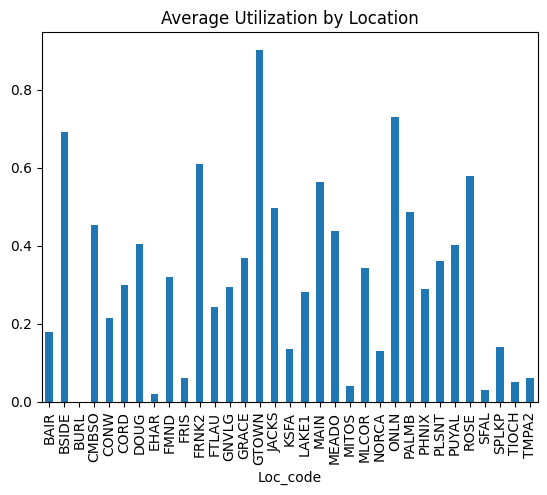

In [ ]:
#Bar chart for Average Utilization
location_summary['Average_utilization'].plot(kind='bar', title='Average Utilization by Location')

<Axes: title={'center': 'Total Demand Gap by Location'}, xlabel='Loc_code'>

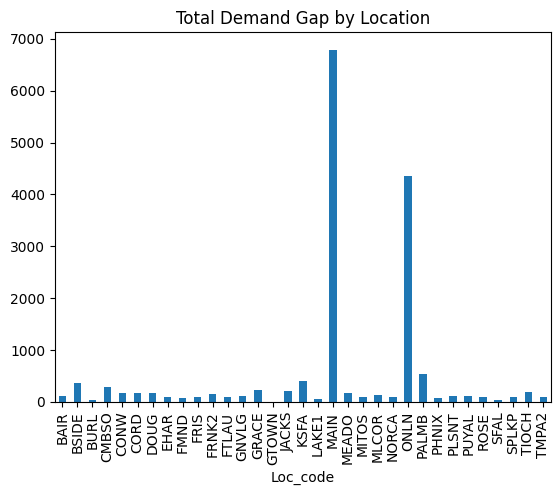

In [ ]:
#Bar Chart for Total Demand Gap
location_summary['Total_Demand_Gap'].plot(kind='bar', title='Total Demand Gap by Location')

<Axes: title={'center': 'Count of Total Courses by Location'}, xlabel='Loc_code'>

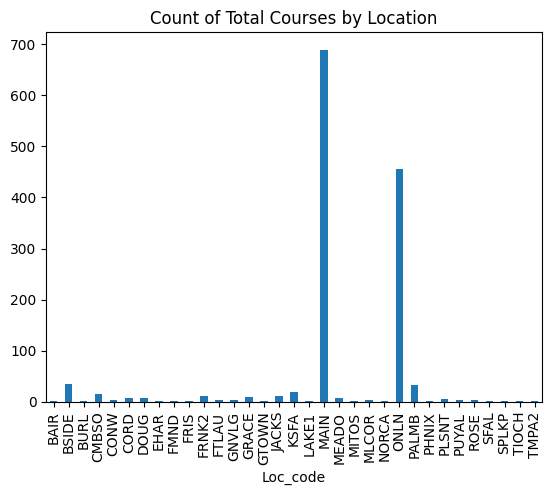

In [ ]:
#Bar Chart for Count of Total Courses
location_summary['Total_courses'].plot(kind='bar', title='Count of Total Courses by Location')

In [ ]:
department_summary = df.groupby('Department').agg({'Enrollment_ratio': 'mean','Demand_gap': 'sum','Crs_enrollment':'count'})
department_summary.head()

,Enrollment_ratio,Demand_gap,Crs_enrollment
Department,,,
ACTG,0.428571,96,7
ARTV,0.660752,152,19
AVIM,0.220000,78,4
AVIP,0.112000,333,15
BBUS,0.659082,493,42


In [ ]:
department_summary= department_summary.rename(columns={'Crs_enrollment': 'Total_courses',
                                                   'Enrollment_ratio':'Average_utilization',
                                                   'Demand_gap': 'Total_Demand_Gap'})
department_summary.head()

,Average_utilization,Total_Demand_Gap,Total_courses
Department,,,
ACTG,0.428571,96,7
ARTV,0.660752,152,19
AVIM,0.220000,78,4
AVIP,0.112000,333,15
BBUS,0.659082,493,42


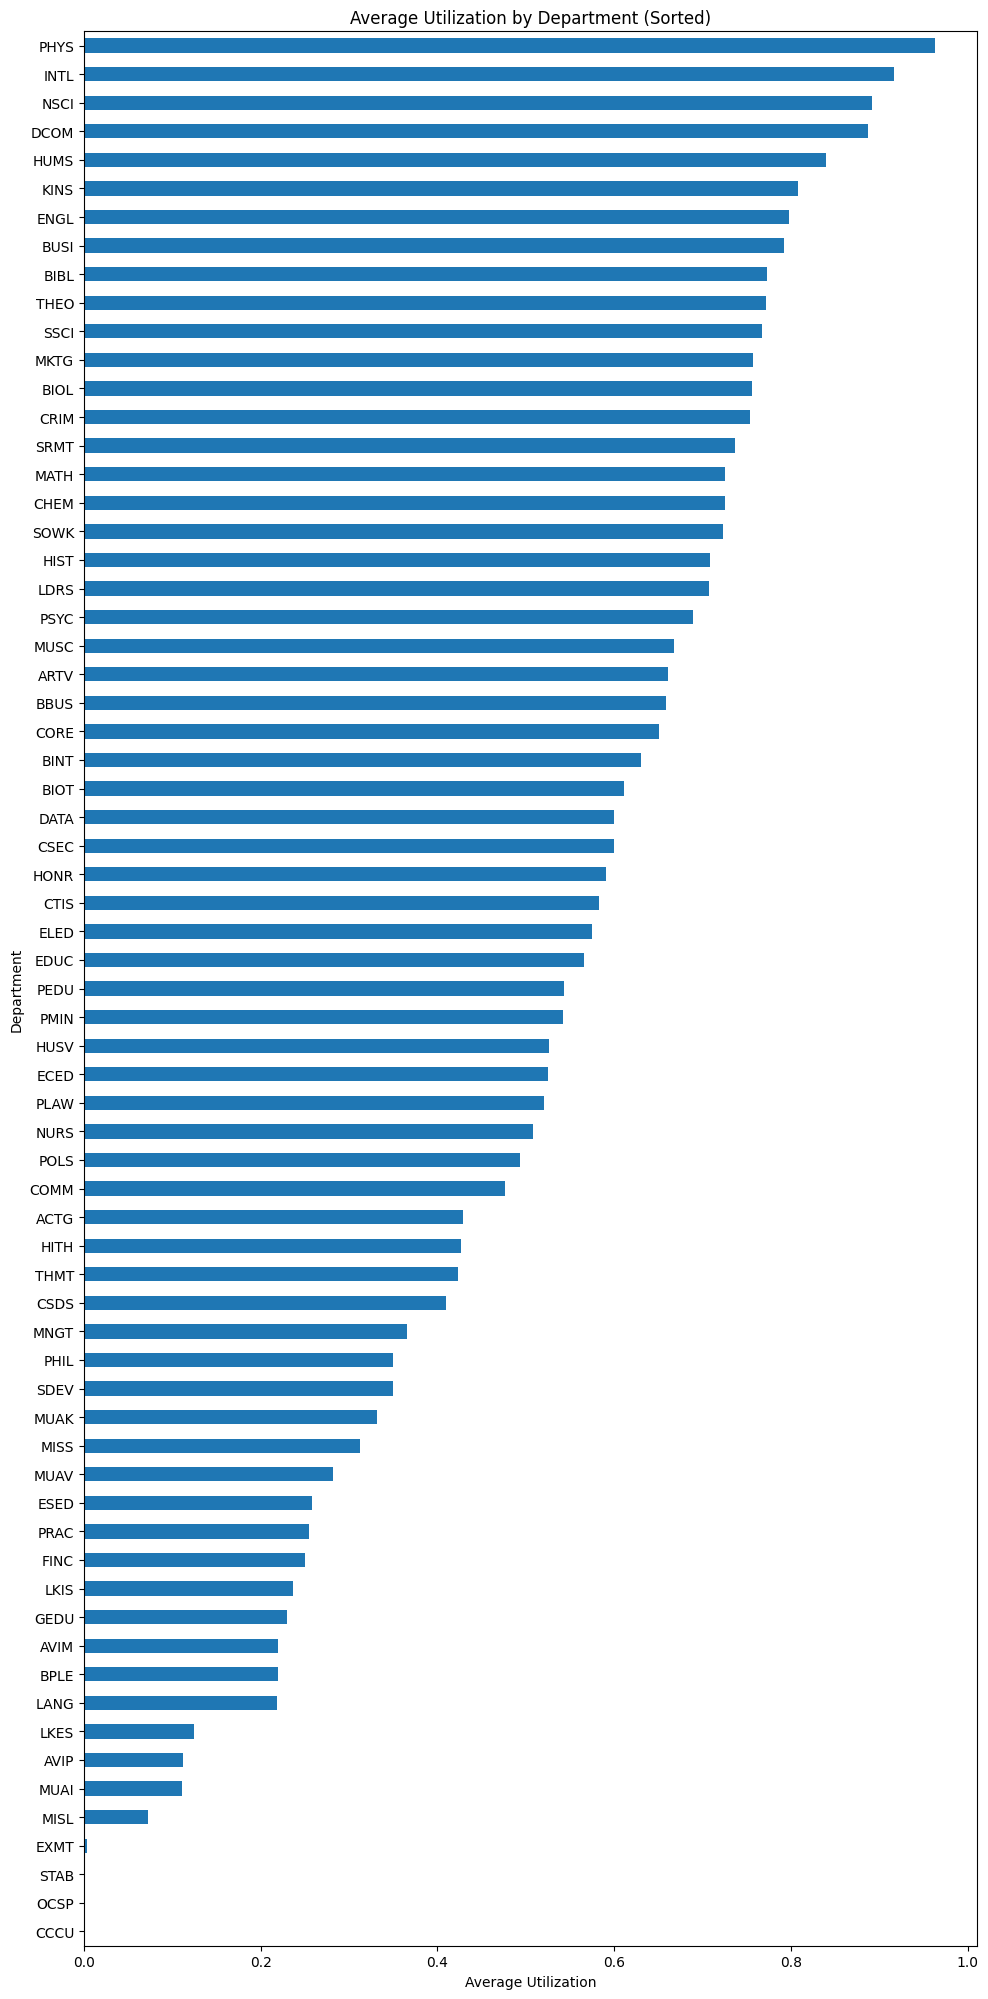

In [ ]:


# Sort the data for better readability
ds_utilization_sorted = department_summary.sort_values('Average_utilization', ascending=True)

# Create a horizontal bar chart
fig, ax = plt.subplots(figsize=(10, ds_utilization_sorted.shape[0] * 0.3))
ds_utilization_sorted['Average_utilization'].plot(
    kind='barh',
    ax=ax,
    title='Average Utilization by Department (Sorted)',
    xlabel='Average Utilization',
    ylabel='Department'
)
plt.tight_layout()
plt.show()

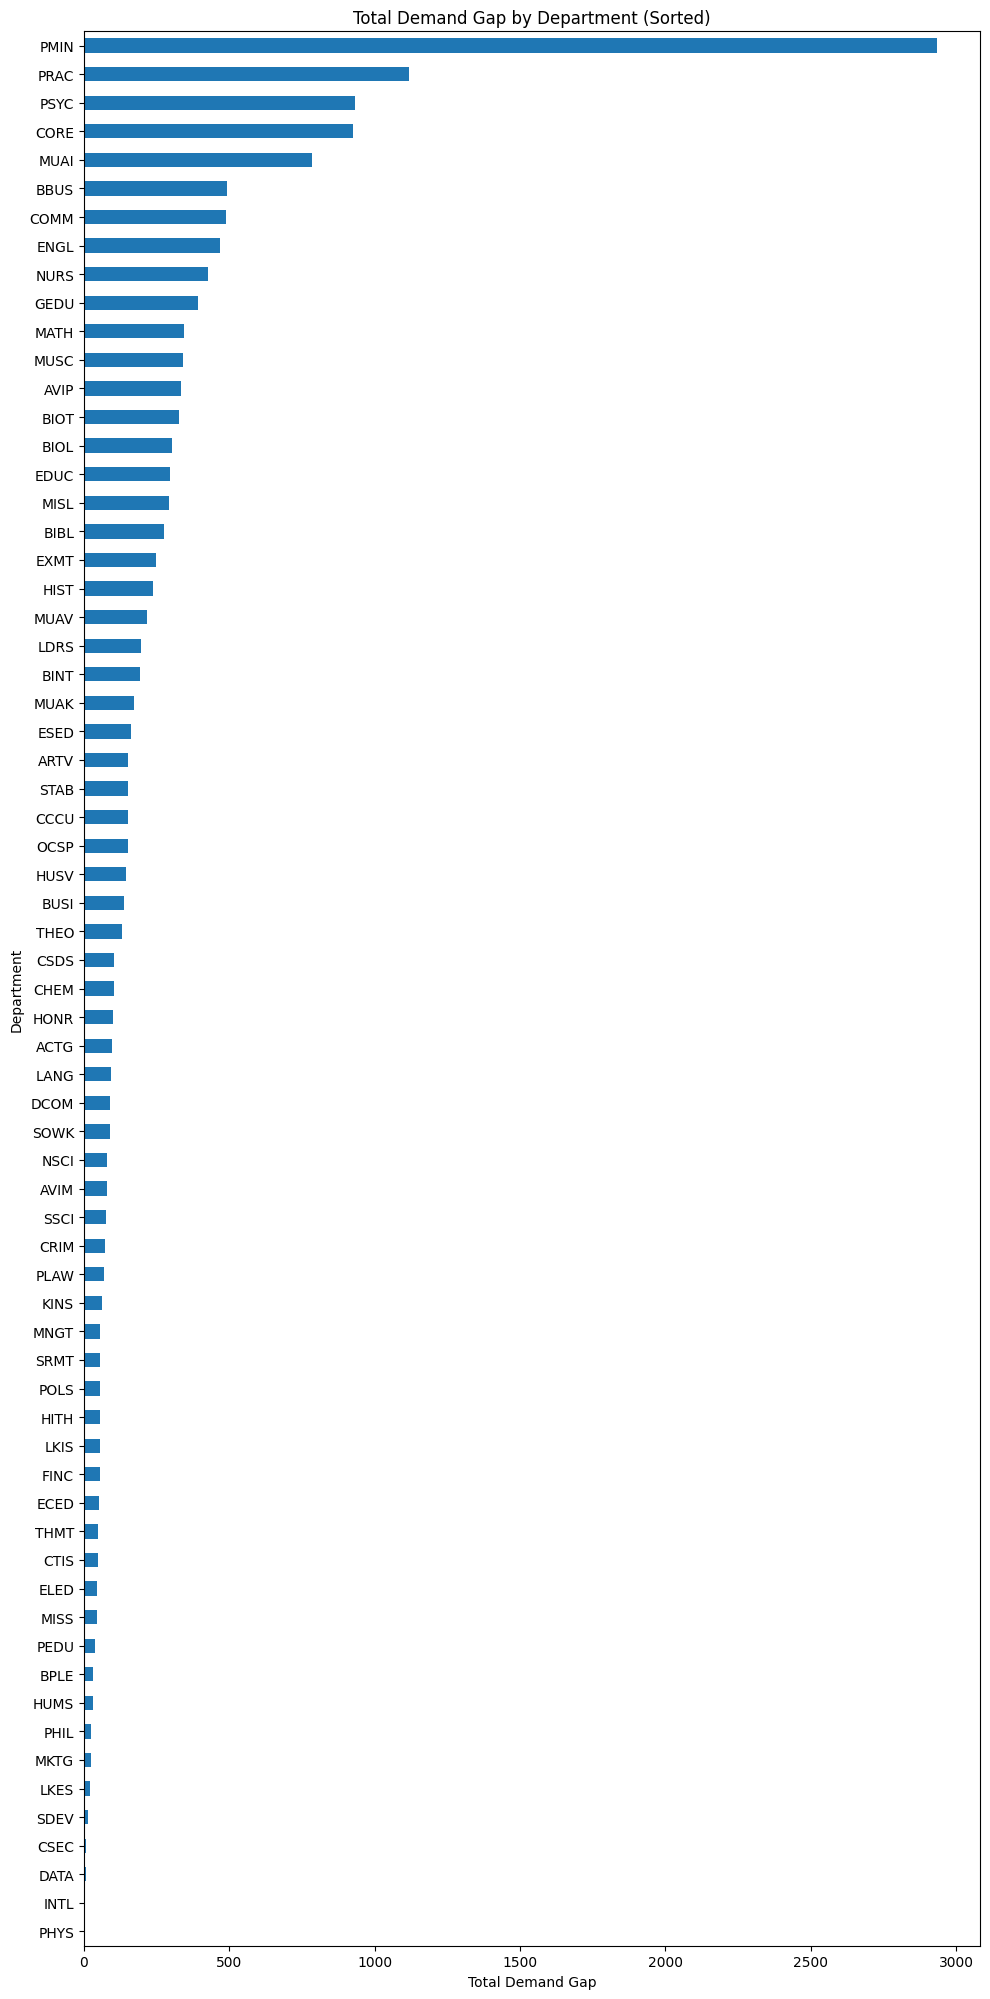

In [ ]:
ds_demandgap_sorted = department_summary.sort_values('Total_Demand_Gap', ascending=True)

fig, ax = plt.subplots(figsize=(10, ds_demandgap_sorted.shape[0] * 0.3))
ds_demandgap_sorted['Total_Demand_Gap'].plot(
    kind='barh',
    ax=ax,
    title='Total Demand Gap by Department (Sorted)',
    xlabel='Total Demand Gap',
    ylabel='Department'
)
plt.tight_layout()
plt.show()

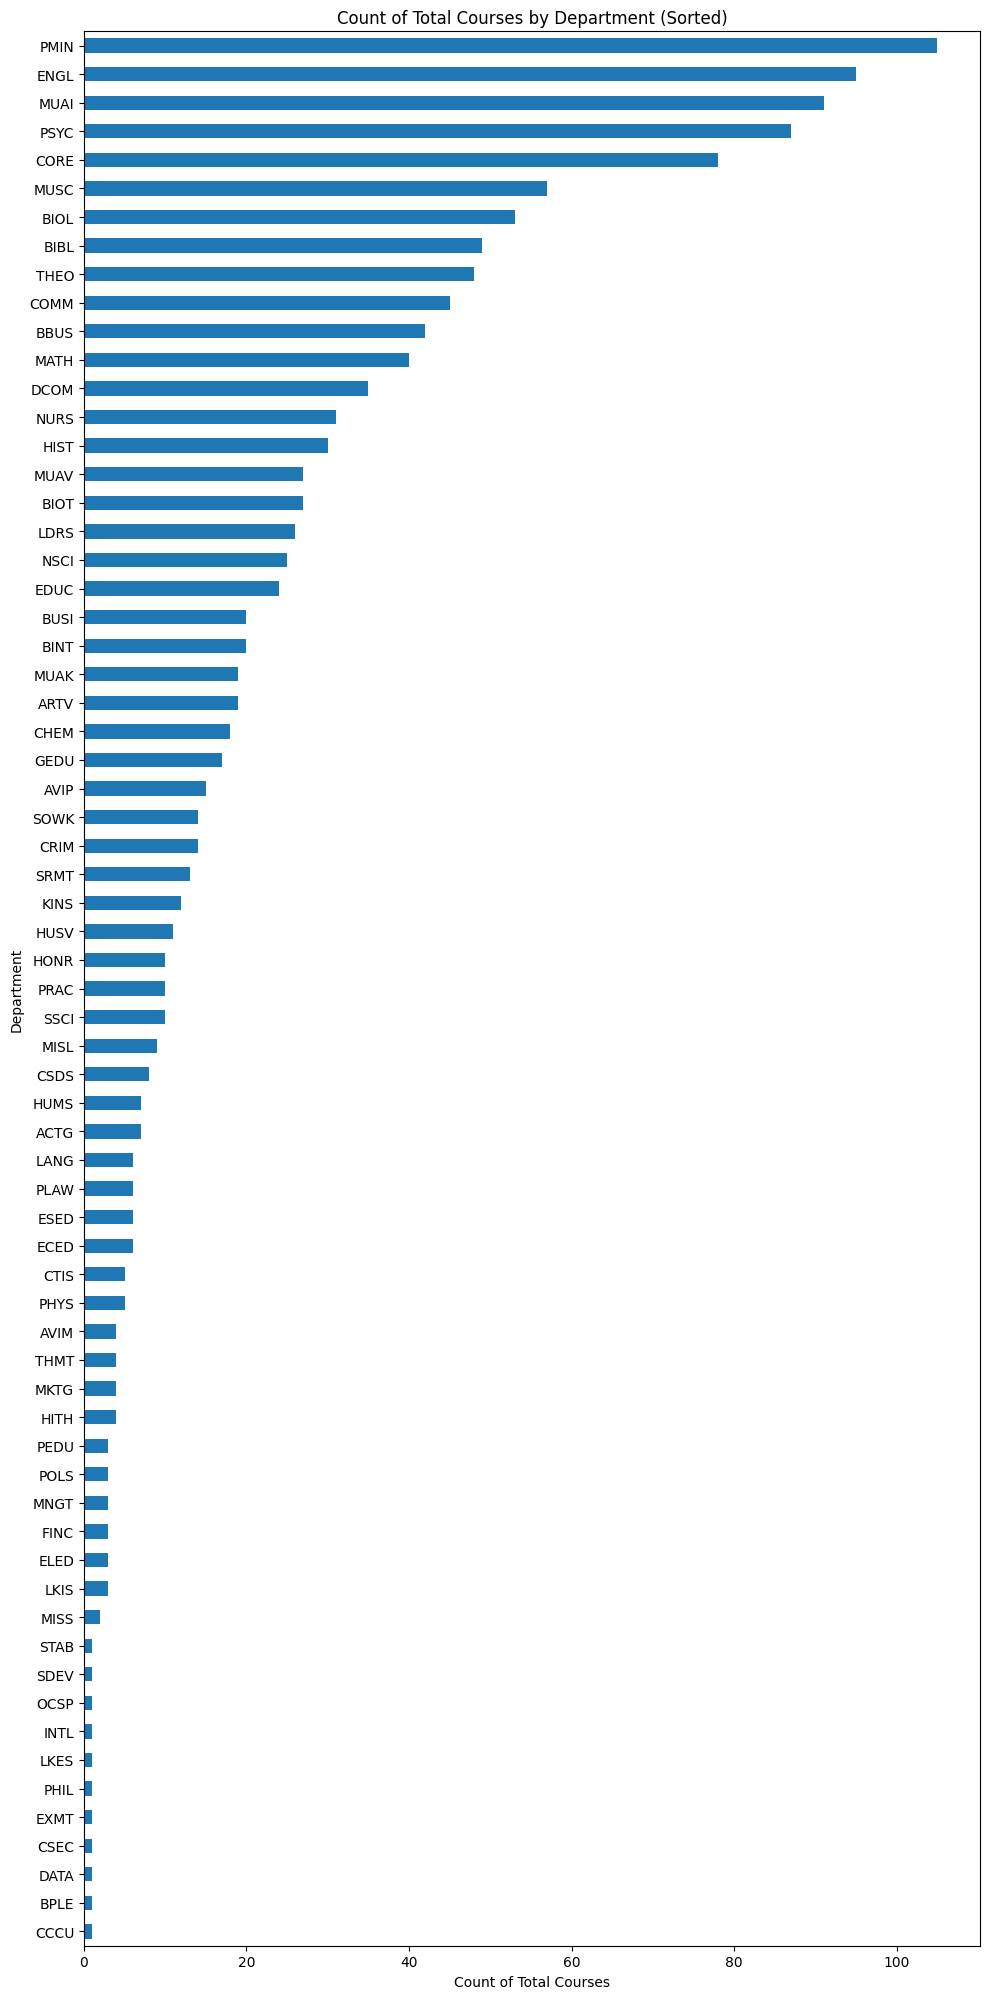

In [ ]:
ds_courses_sorted = department_summary.sort_values('Total_courses', ascending=True)

fig, ax = plt.subplots(figsize=(10, ds_courses_sorted.shape[0]* 0.3))
ds_courses_sorted['Total_courses'].plot(
    kind='barh',
    ax=ax,
    title='Count of Total Courses by Department (Sorted)',
    xlabel='Count of Total Courses',
    ylabel='Department'
)

plt.tight_layout()
plt.show()